## Import Liblary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.ensemble import RandomForestClassifier

## Data Loading

In [2]:
df = pd.read_csv('/content/credit_cleaned_data.csv')

In [3]:
df.head()

,SK_ID_CURR,TARGET,CODE_GENDER,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,...,FLAG_OWN_REALTY,NAME_HOUSING_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,REGION_RATING_CLIENT,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE,YEARS_EMPLOYED
0,100002,1,M,0,202500.0,406597.5,24700.5,351000.0,Secondary,Single,...,Y,House / apartment,0.262949,0.139376,2.0,0.0,0.0,1.0,25,1
1,100003,0,F,0,270000.0,1293502.5,35698.5,1129500.0,Higher education,Married,...,N,House / apartment,0.622246,0.535276,1.0,0.0,0.0,0.0,45,3
2,100004,0,M,0,67500.0,135000.0,6750.0,135000.0,Secondary,Single,...,Y,House / apartment,0.555912,0.729567,2.0,0.0,0.0,0.0,52,0
3,100006,0,F,0,135000.0,312682.5,29686.5,297000.0,Secondary,Civil marriage,...,Y,House / apartment,0.650442,0.535276,2.0,0.0,0.0,0.0,52,8
4,100007,0,M,0,121500.0,513000.0,21865.5,513000.0,Secondary,Single,...,Y,House / apartment,0.322738,0.535276,2.0,0.0,0.0,0.0,54,8


## Dataset Overview

In [7]:
df.shape

(9692, 24)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9692 entries, 0 to 9691
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   SK_ID_CURR                  9692 non-null   int64  
 1   TARGET                      9692 non-null   int64  
 2   CODE_GENDER                 9692 non-null   object 
 3   CNT_CHILDREN                9692 non-null   int64  
 4   AMT_INCOME_TOTAL            9692 non-null   float64
 5   AMT_CREDIT                  9692 non-null   float64
 6   AMT_ANNUITY                 9692 non-null   float64
 7   AMT_GOODS_PRICE             9692 non-null   float64
 8   NAME_EDUCATION_TYPE         9692 non-null   object 
 9   NAME_FAMILY_STATUS          9692 non-null   object 
 10  NAME_INCOME_TYPE            9692 non-null   object 
 11  OCCUPATION_TYPE             9692 non-null   object 
 12  CNT_FAM_MEMBERS             9692 non-null   float64
 13  FLAG_OWN_CAR                9692 

In [9]:
df.isnull().sum()

,0
SK_ID_CURR,0
TARGET,0
CODE_GENDER,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
AMT_CREDIT,0
AMT_ANNUITY,0
AMT_GOODS_PRICE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0


In [10]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CNT_FAM_MEMBERS,EXT_SOURCE_2,EXT_SOURCE_3,REGION_RATING_CLIENT,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE,YEARS_EMPLOYED
count,9692.000000,9692.000000,9692.000000,9.692000e+03,9.692000e+03,9692.000000,9.692000e+03,9692.000000,9692.000000,9692.000000,9692.000000,9692.000000,9692.000000,9692.000000,9692.000000,9692.000000
mean,105652.346574,0.077899,0.415600,1.676262e+05,6.013997e+05,27100.230396,5.409653e+05,2.156108,0.516072,0.516760,2.045398,0.239063,0.232460,1.632480,43.416323,182.380004
std,3256.587947,0.268027,0.718289,9.466657e+04,4.040238e+05,14419.822666,3.713718e+05,0.903382,0.189084,0.175879,0.510343,0.871776,0.578327,1.848031,11.896742,379.710154
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,2596.500000,4.500000e+04,1.000000,0.000074,0.000527,1.000000,0.000000,0.000000,0.000000,21.000000,0.000000
25%,102827.750000,0.000000,0.000000,1.125000e+05,2.700000e+05,16434.000000,2.385000e+05,2.000000,0.395288,0.422370,2.000000,0.000000,0.000000,0.000000,33.000000,2.000000
50%,105665.500000,0.000000,0.000000,1.440000e+05,5.123925e+05,24970.500000,4.500000e+05,2.000000,0.566171,0.535276,2.000000,0.000000,0.000000,1.000000,43.000000,6.000000
75%,108462.250000,0.000000,1.000000,2.025000e+05,8.100000e+05,34671.375000,6.840000e+05,3.000000,0.664487,0.638044,2.000000,0.000000,0.000000,3.000000,53.000000,15.000000
max,111275.000000,1.000000,7.000000,1.935000e+06,2.961000e+06,135936.000000,2.961000e+06,9.000000,0.855000,0.885488,3.000000,16.000000,8.000000,13.000000,68.000000,1000.000000


## TARGET Distribution

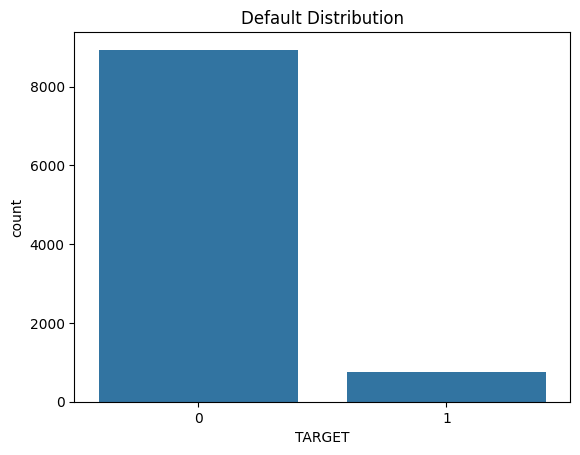

In [12]:
sns.countplot(
    x='TARGET',
    data=df
)

plt.title('Default Distribution')
plt.show()

Dataset imbalance sehingga perlu SMOTE untuk ml modelling

## Numerical Analysis

In [13]:
num_cols = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'AGE',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

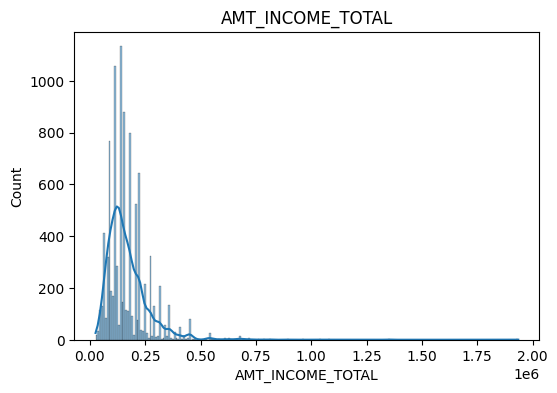

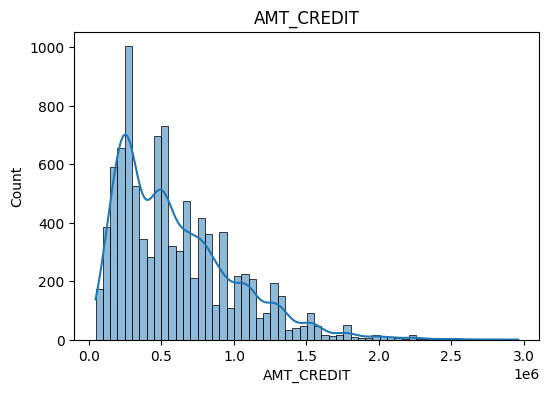

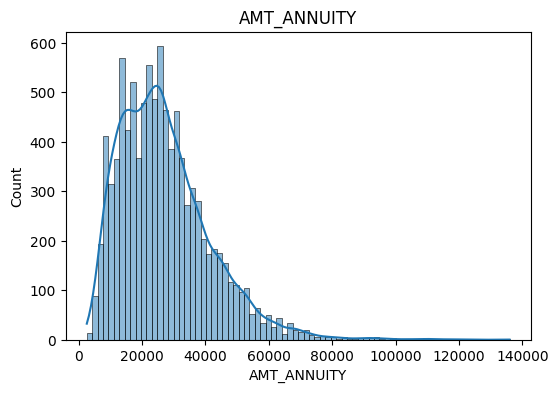

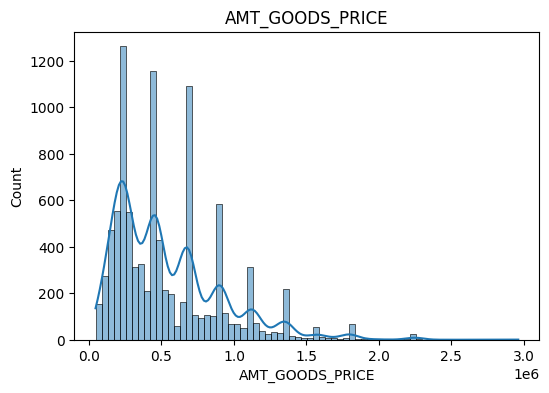

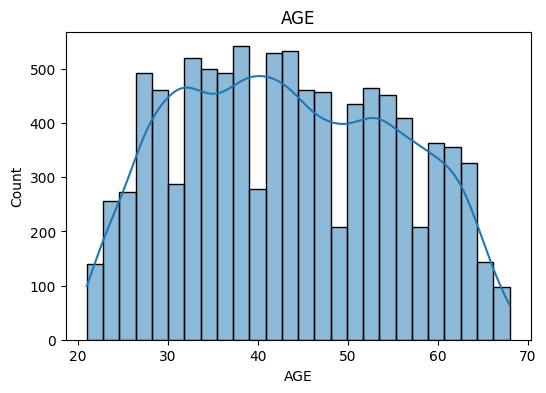

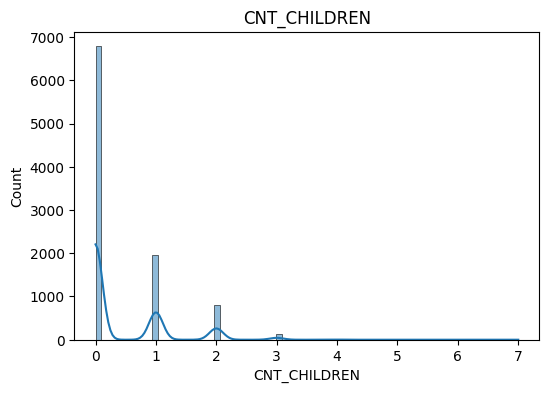

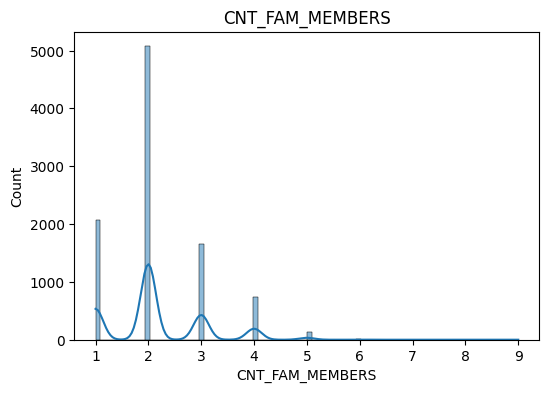

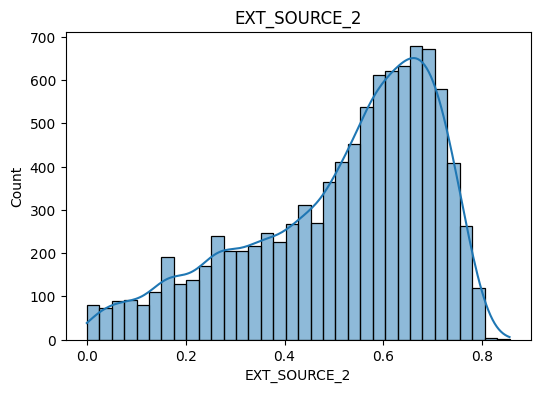

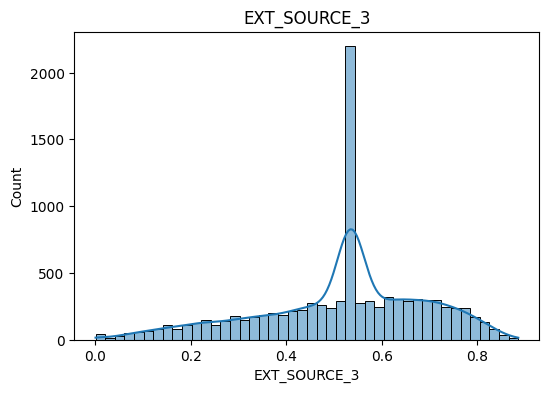

In [14]:
for col in num_cols:
    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)
    plt.show()

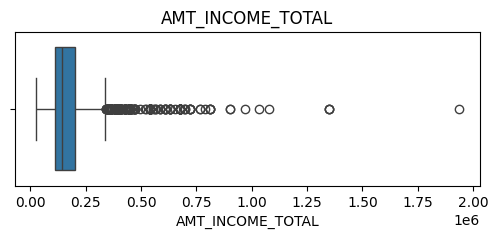

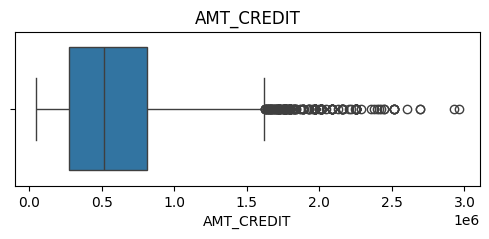

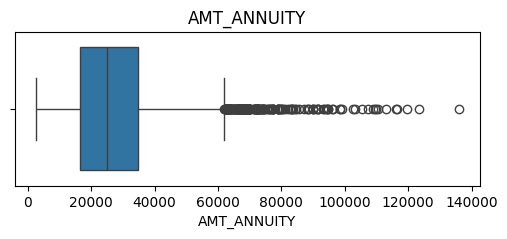

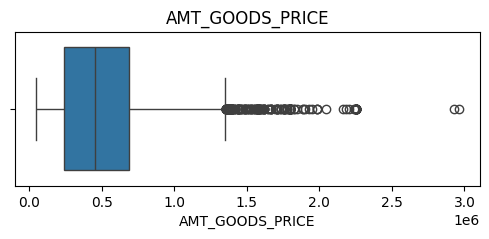

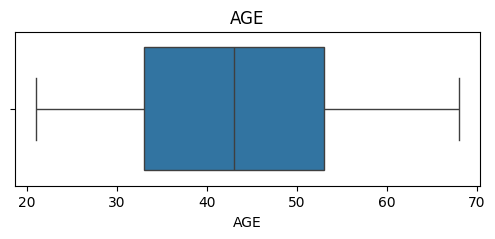

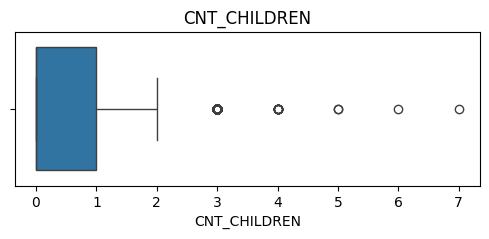

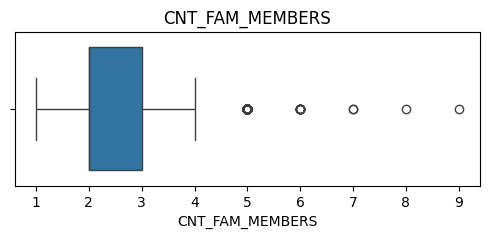

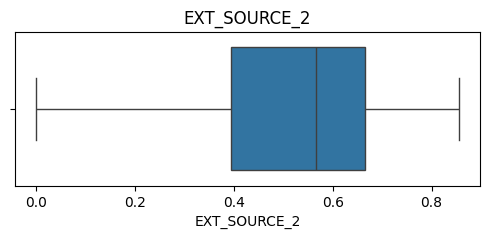

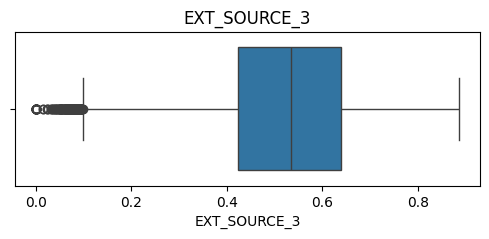

In [15]:
for col in num_cols:
    plt.figure(figsize=(6,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)
    plt.show()

## Default Comparison

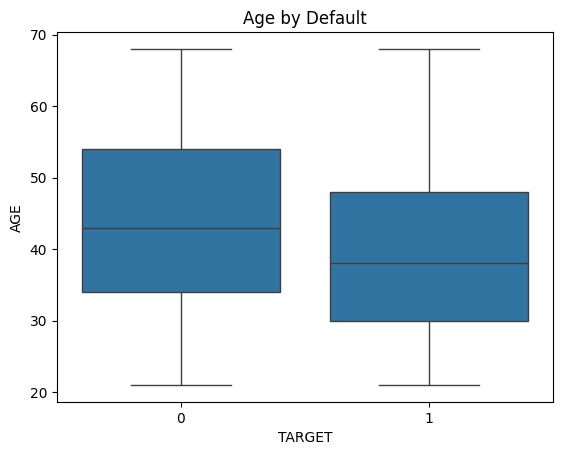

In [16]:
sns.boxplot(
    x='TARGET',
    y='AGE',
    data=df
)

plt.title(
    'Age by Default'
)
plt.show()

<Axes: xlabel='TARGET', ylabel='AMT_INCOME_TOTAL'>

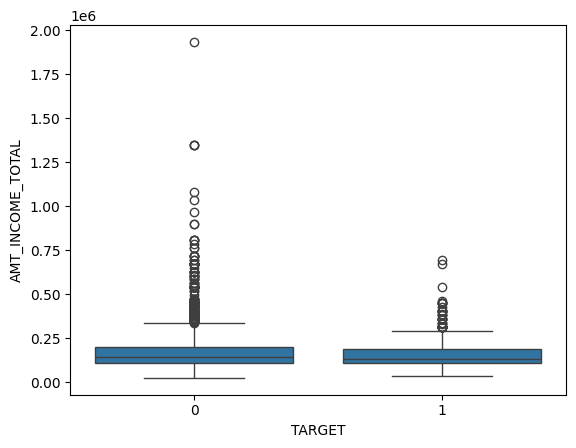

In [17]:
sns.boxplot(
    x='TARGET',
    y='AMT_INCOME_TOTAL',
    data=df
)

<Axes: xlabel='TARGET', ylabel='AMT_CREDIT'>

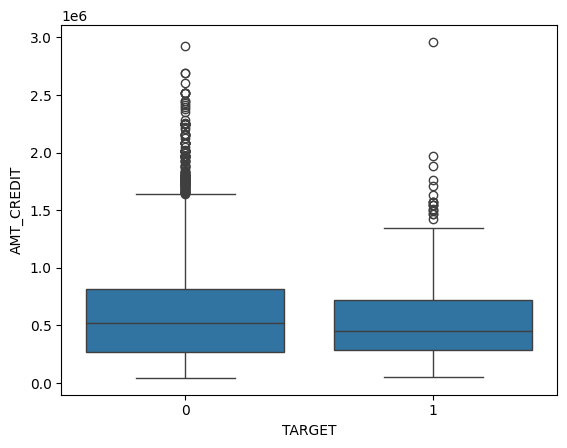

In [18]:
sns.boxplot(
    x='TARGET',
    y='AMT_CREDIT',
    data=df
)

<Axes: xlabel='TARGET', ylabel='EXT_SOURCE_2'>

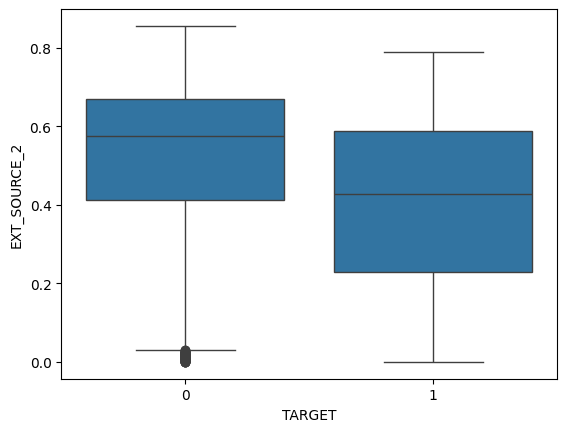

In [19]:
sns.boxplot(
    x='TARGET',
    y='EXT_SOURCE_2',
    data=df
)

## Categorical Analysis

In [20]:
pd.crosstab(
    df['NAME_EDUCATION_TYPE'],
    df['TARGET'],
    normalize='index'
) * 100

TARGET,0,1
NAME_EDUCATION_TYPE,,
Academic degree,100.000000,0.000000
Higher education,95.648464,4.351536
Incomplete higher,89.285714,10.714286
Lower secondary,89.473684,10.526316
Secondary,91.216118,8.783882


In [21]:
pd.crosstab(
    df['CODE_GENDER'],
    df['TARGET'],
    normalize='index'
) *100

TARGET,0,1
CODE_GENDER,,
F,93.287543,6.712457
M,90.109556,9.890444


In [22]:
pd.crosstab(
    df['NAME_HOUSING_TYPE'],
    df['TARGET'],
    normalize='index'
) *100

TARGET,0,1
NAME_HOUSING_TYPE,,
Co-op apartment,91.111111,8.888889
House / apartment,92.632315,7.367685
Municipal apartment,90.190736,9.809264
Office apartment,91.780822,8.219178
Rented apartment,85.897436,14.102564
With parents,88.372093,11.627907


In [23]:
pd.crosstab(
    df['FLAG_OWN_REALTY'],
    df['TARGET'],
    normalize='index'
) *100

TARGET,0,1
FLAG_OWN_REALTY,,
N,91.564208,8.435792
Y,92.489651,7.510349


## Heatmap

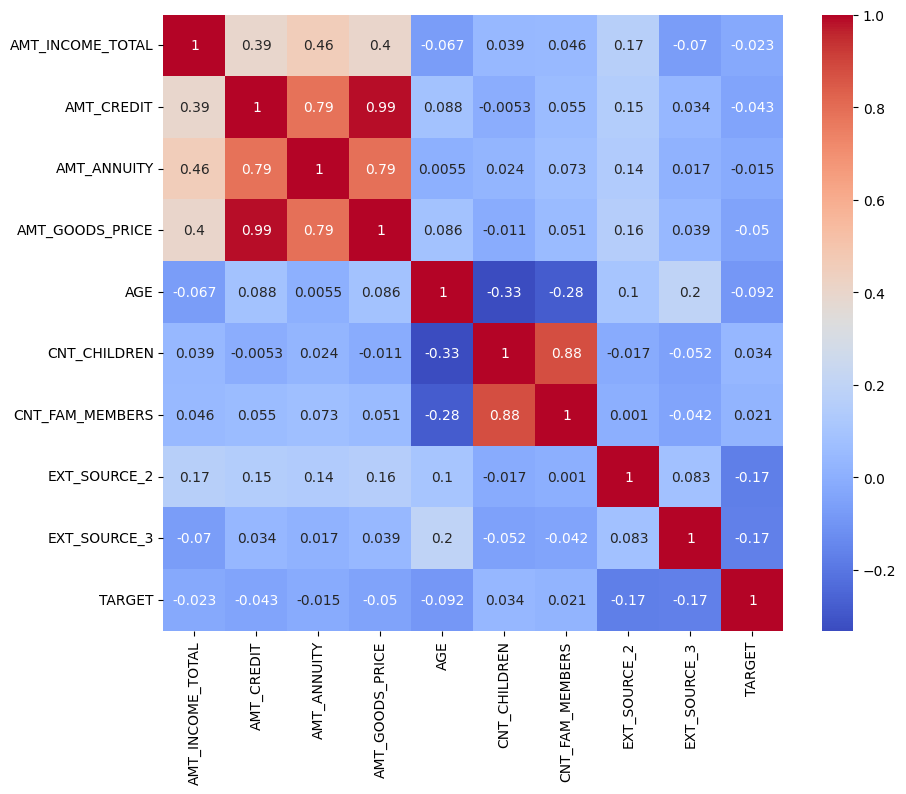

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[num_cols + ['TARGET']]
    .corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [25]:
important_cols = [
    'AGE',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'EXT_SOURCE_2',
    'TARGET'
]

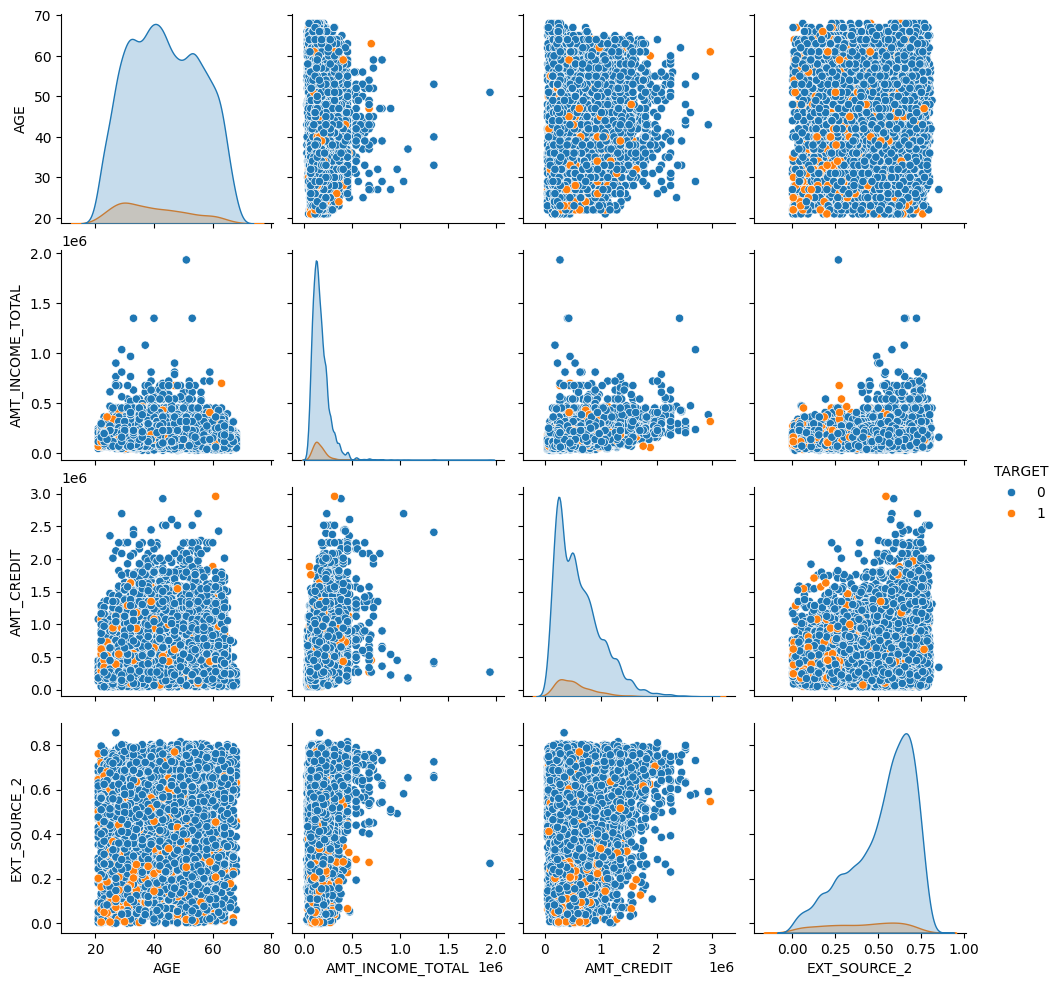

In [26]:
sns.pairplot(
    df[important_cols],
    hue='TARGET'
)

plt.show()